<a href="https://colab.research.google.com/github/kowshika-santhosh-2111data/Driver_Drowsiness_Detection/blob/main/MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"

classes = ["Open", "Closed", "yawn", "no_yawn"]

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"))

['yawn', 'Open', 'no_yawn', 'Closed']


In [ ]:
classes = ["Open", "Closed", "yawn", "no_yawn"]

X = []
y = []

for label, class_name in enumerate(classes):
    folder = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)

        img = cv2.imread(image_path)
        img = cv2.resize(img, (224, 224))
        img = preprocess_input(img.astype("float32"))

        X.append(img)
        y.append(label)

In [ ]:
X = np.array(X)
y = np.array(y)

In [ ]:
x_train_mobile, x_test_mobile, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

output = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,980 (9.24 MB)

 Trainable params: 164,740 (643.52 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [ ]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2
)

checkpoint = ModelCheckpoint(
    "mobilenet_best.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
history = model.fit(
    x_train_mobile,
    y_train,
    validation_data=(x_test_mobile, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 54s 487ms/step - accuracy: 0.6302 - loss: 0.9143 - val_accuracy: 0.7828 - val_loss: 0.4596 - learning_rate: 1.0000e-04
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8164 - loss: 0.4729 - val_accuracy: 0.8707 - val_loss: 0.3011 - learning_rate: 1.0000e-04
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8435 - loss: 0.3531 - val_accuracy: 0.8810 - val_loss: 0.2518 - learning_rate: 1.0000e-04
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8711 - loss: 0.3056 - val_accuracy: 0.9069 - val_loss: 0.2219 - learning_rate: 1.0000e-04
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8841 - loss: 0.2842 - val_accuracy: 0.9207 - val_loss: 0.1941 - learning_rate: 1.0000e-04
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8983 - loss: 0.2490 - val_accuracy: 0.9379 - val_loss: 0.1863 - learning_rate: 1.0000e-04
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.906

In [ ]:
model.save("mobilenet_driver_drowsiness.keras")
print("Model saved successfully")

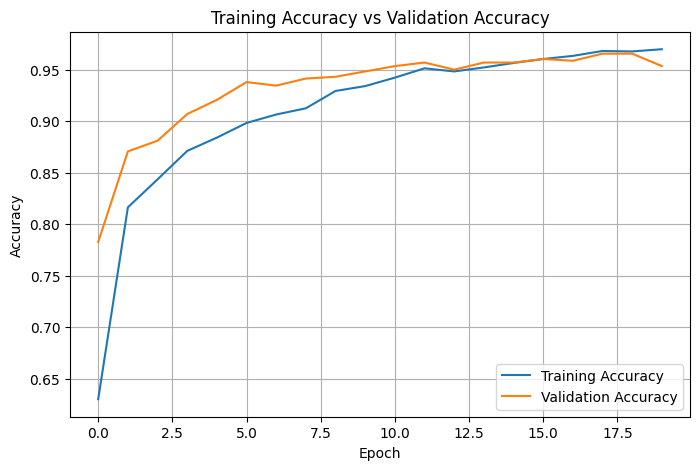

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training Accuracy vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

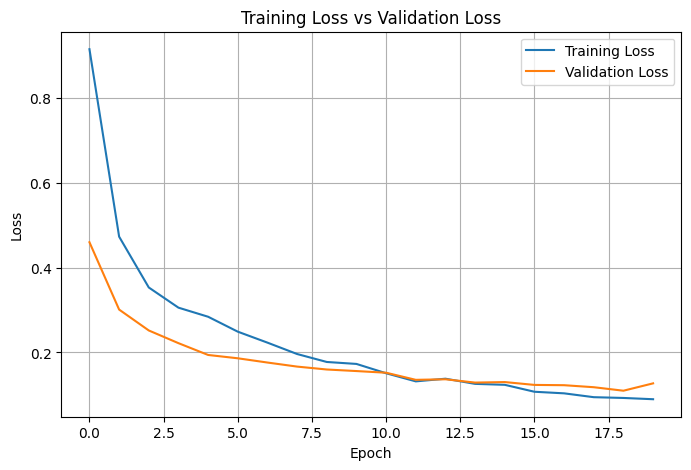

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#predict test data
y_pred = model.predict(x_test_mobile)
y_pred_labels = np.argmax(y_pred, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step


In [ ]:
classes = ["Open","Closed","yawn","no_yawn"]

print("Prediction Distribution")

unique, counts = np.unique(y_pred_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{classes[u]} : {c}")

Prediction Distribution
Open : 144
Closed : 146
yawn : 140
no_yawn : 150


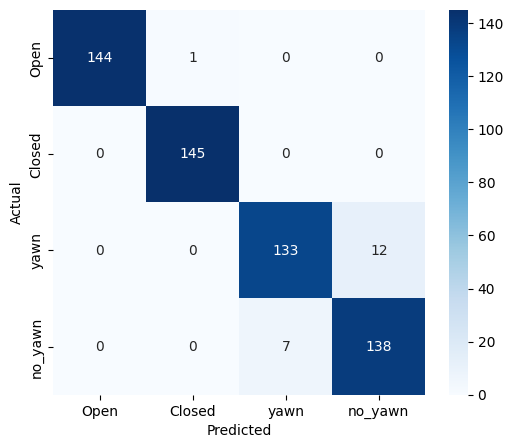

In [ ]:
labels = ["Open", "Closed", "yawn", "no_yawn"]
cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:

print(classification_report(
    y_test,
    y_pred_labels,
    target_names=classes
))

              precision    recall  f1-score   support

        Open       1.00      0.99      1.00       145
      Closed       0.99      1.00      1.00       145
        yawn       0.95      0.92      0.93       145
     no_yawn       0.92      0.95      0.94       145

    accuracy                           0.97       580
   macro avg       0.97      0.97      0.97       580
weighted avg       0.97      0.97      0.97       580



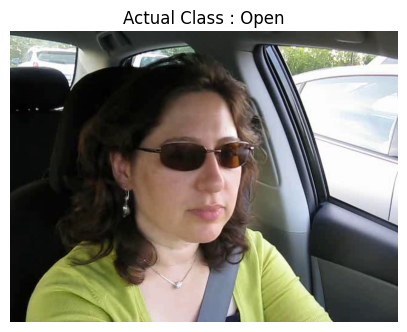

Actual Class    : Open
Predicted Class : yawn
Confidence      : 50.27%


In [ ]:
base_path = "/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"
selected_class = "Open"
image_name = "_100.jpg"

image_path = os.path.join(base_path, selected_class,image_name)
img = cv2.imread(image_path)

if img is None:
  raise ValueError)f"Could not read image: {image_path}"
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Actual Class : {selected_class}")
plt.show()

img_input = cv2.resize(img,(224,224))
img_input = img_input.astype("float32")/255.0
img_input = np.expand_dims(img_input,axis=0)

prediction = model.predict(img_input,verbose=0)

pred_class = np.argmax(prediction)
confidence = np.max(prediction)*100

print("Actual Class    :",selected_class)
print("Predicted Class :",classes[pred_class])
print(f"Confidence      : {confidence:.2f}%")

In [ ]:
fatigue_levels=[]

for cls in y_pred_labels:

    if cls in [0,3]:
        fatigue_levels.append(0)

    elif cls==2:
        fatigue_levels.append(1)

    elif cls==1:
        fatigue_levels.append(2)

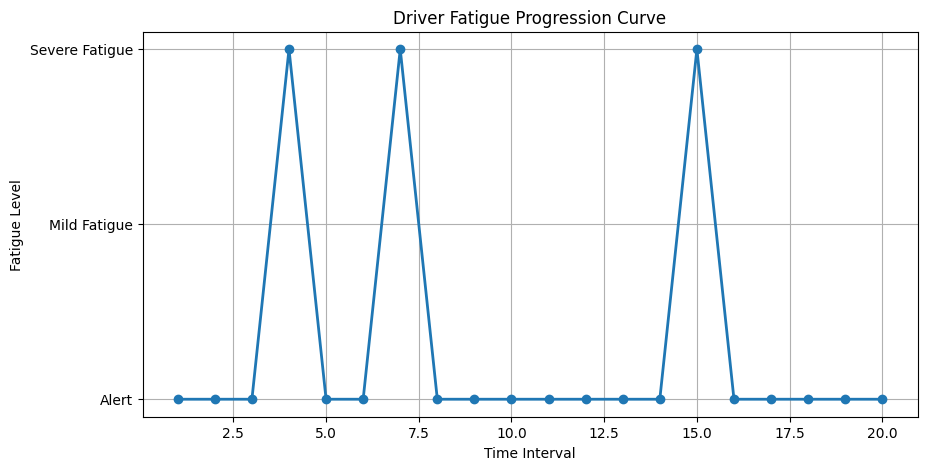

In [ ]:
frames_per_interval=30

progression=[]

for i in range(0,len(fatigue_levels),frames_per_interval):

    interval=fatigue_levels[i:i+frames_per_interval]

    dominant=np.bincount(interval).argmax()

    progression.append(dominant)

plt.figure(figsize=(10,5))

plt.plot(
    range(1,len(progression)+1),
    progression,
    marker='o',
    linewidth=2
)

plt.yticks(
    [0,1,2],
    ['Alert','Mild Fatigue','Severe Fatigue']
)

plt.xlabel("Time Interval")
plt.ylabel("Fatigue Level")
plt.title("Driver Fatigue Progression Curve")

plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_labels)
precision = precision_score(y_test, y_pred_labels, average='weighted')
recall = recall_score(y_test, y_pred_labels, average='weighted')
f1 = f1_score(y_test, y_pred_labels, average='weighted')

print("="*50)
print("        PERFORMANCE ANALYSIS")
print("="*50)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("\nModel Analysis:")

if accuracy >= 0.90:
    print("Excellent model performance.")
elif accuracy >= 0.80:
    print("Very good model performance.")
elif accuracy >= 0.70:
    print("Good model performance.")
elif accuracy >= 0.60:
    print("Moderate performance. Further improvement is possible.")
else:
    print("Low performance. More training or fine-tuning is recommended.")

print("\nConclusion:")
print("• MobileNetV2 successfully classifies driver drowsiness into four classes.")
print("• Transfer learning enables efficient feature extraction from facial images.")
print("• The model can be integrated into a real-time driver monitoring system.")
print("• Performance can be further improved using a larger and more diverse dataset.")

        PERFORMANCE ANALYSIS
Accuracy : 96.55%
Precision: 96.58%
Recall   : 96.55%
F1 Score : 96.55%

Model Analysis:
Excellent model performance.

Conclusion:
• MobileNetV2 successfully classifies driver drowsiness into four classes.
• Transfer learning enables efficient feature extraction from facial images.
• The model can be integrated into a real-time driver monitoring system.
• Performance can be further improved using a larger and more diverse dataset.
